In [1]:
import pandas as pd
import numpy as np
import os

In [16]:
data_d = '/projects/MARGULIS/youtube-music-comments/data/YouNiverse'

df1 = pd.read_csv(f"{data_d}/df_channels_music.tsv.gz", compression="infer", sep="\t")
df2 = pd.read_feather(f"{data_d}/yt_metadata_helper_music.feather")
df3 = pd.read_csv(f"{data_d}/num_comments_music.tsv.gz", compression="infer", sep="\t")



In [17]:
df3.head()

,display_id,num_comms
0,WVapFh7cx3M,28.0
1,IyfriHeXo3I,126.0
2,O0N0fH41wGw,190.0
3,H20js4rsYeI,6.0
4,bM06MQ--Daw,3.0


In [18]:
df1.head()


,category_cc,join_date,channel,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,videos_yt
0,Music,2008-03-17,UCXhkGgooXHDNwgJXmoTSN7g,Mago Merlino,14800,838,707828.0,838.0
1,Music,2011-05-28,UC1WpidoYChUGcyHAcnALQIg,magrosi65,64900,1497,219166.0,1487.0
2,Music,2015-08-11,UCLVAbmicv2u1x7fgO4fLbng,Mags Lyrics,10700,66,884480.0,38.0
3,Music,2011-09-21,UC5tOdNsy1E3RhuZjLLA2cVA,Magun Haokip,10438,171,793000.0,154.0
4,Music,2006-07-26,UC8gEQRDAB7aGC18a8IcBkuw,ekleroshock,66800,142,209716.0,137.0


In [19]:
df2.head()

,categories,channel_id,dislike_count,display_id,duration,like_count,upload_date,view_count,dummmy
2658,Music,UCzWfqsjlvzAOUozsGFR3kbg,28.0,WVapFh7cx3M,142,184.0,2016-06-06,4360.0,1
3053,Music,UCzWfqsjlvzAOUozsGFR3kbg,126.0,IyfriHeXo3I,35,1037.0,2015-06-04,43190.0,1
3220,Music,UCzWfqsjlvzAOUozsGFR3kbg,112.0,O0N0fH41wGw,140,1193.0,2015-01-05,41416.0,1
3591,Music,UCzWdpFOflXTOk5Gsi2aJ67g,0.0,H20js4rsYeI,112,102.0,2019-10-02,2643.0,1
3592,Music,UCzWdpFOflXTOk5Gsi2aJ67g,1.0,bM06MQ--Daw,157,63.0,2019-10-01,1304.0,1


In [20]:
df3.head()

,display_id,num_comms
0,WVapFh7cx3M,28.0
1,IyfriHeXo3I,126.0
2,O0N0fH41wGw,190.0
3,H20js4rsYeI,6.0
4,bM06MQ--Daw,3.0


In [21]:

#filters out videos with <= 100 comments
df3 = df3[df3['num_comms'] >= 100].copy()

# separates videos into low, medium, high comment bins
labels = ['low', 'medium', 'high']
bins = [-float('inf'), 500, 1000, float('inf')]

df3['size_fixed'] = pd.cut(df3['num_comms'], bins=bins, labels=labels, include_lowest=True)
df3['size_fixed'] = df3['size_fixed'].astype(pd.CategoricalDtype(categories=labels, ordered=True))


# counts and aggregated summary stats
print("Counts per bin:")
print(df3['size_fixed'].value_counts(dropna=False).reindex(labels))

print("\nSummary stats per bin:")
print(df3.groupby('size_fixed', observed=False)['num_comms']
      .agg(['count','mean','median','std','min','max'])
      .reindex(labels))





Counts per bin:
size_fixed
low       586405
medium    107360
high      121396
Name: count, dtype: int64

Summary stats per bin:
             count         mean  median           std     min        max
size_fixed                                                              
low         586405   214.699846   181.0    103.441734   100.0      500.0
medium      107360   700.731082   677.0    140.814352   501.0     1000.0
high        121396  5358.568915  2023.0  17608.056162  1001.0  1065672.0


In [22]:
## views per comment ratio

df_merge = df2.merge(df3, on='display_id', how='inner') 
df_merge['views_per_comment'] = np.where(df_merge['num_comms'] > 0,
    df_merge['view_count'] / df_merge['num_comms'],
    np.nan)
print(df_merge[['display_id','view_count','num_comms','views_per_comment']].head())
print(df_merge['views_per_comment'].describe())

    display_id  view_count  num_comms  views_per_comment
0  IyfriHeXo3I     43190.0      126.0         342.777778
1  O0N0fH41wGw     41416.0      190.0         217.978947
2  dlHivlmgasc     96665.0      108.0         895.046296
3  i5jLt1rTL5k    421863.0      259.0        1628.814672
4  kb2BOY2hSqY    107586.0      134.0         802.880597
count    8.151610e+05
mean     1.953912e+03
std      4.191334e+03
min      2.868344e-01
25%      3.336710e+02
50%      8.686380e+02
75%      2.213309e+03
max      1.290304e+06
Name: views_per_comment, dtype: float64


In [23]:
## likes per dislikes ratio

df_merge['likes_per_dislikes'] = np.where(df_merge['dislike_count']>0, df_merge['like_count'] / df_merge['dislike_count'], np.nan)
print(df_merge[['display_id','like_count','dislike_count','likes_per_dislikes']].head())
print(df_merge['likes_per_dislikes'].describe())

    display_id  like_count  dislike_count  likes_per_dislikes
0  IyfriHeXo3I      1037.0          126.0            8.230159
1  O0N0fH41wGw      1193.0          112.0           10.651786
2  dlHivlmgasc      2136.0           22.0           97.090909
3  i5jLt1rTL5k      6687.0          152.0           43.993421
4  kb2BOY2hSqY      2386.0           85.0           28.070588
count    809069.000000
mean         61.745940
std          82.148782
min           0.000000
25%          21.307651
50%          40.847826
75%          73.707792
max       12171.400000
Name: likes_per_dislikes, dtype: float64


In [24]:
## comments per likes ratio

df_merge['comments_per_likes'] = np.where(df_merge['like_count']>0, df_merge['num_comms'] / df_merge['like_count'], np.nan)
print(df_merge[['display_id','like_count','num_comms','comments_per_likes']].head())
print(df_merge['comments_per_likes'].describe())

    display_id  like_count  num_comms  comments_per_likes
0  IyfriHeXo3I      1037.0      126.0            0.121504
1  O0N0fH41wGw      1193.0      190.0            0.159262
2  dlHivlmgasc      2136.0      108.0            0.050562
3  i5jLt1rTL5k      6687.0      259.0            0.038732
4  kb2BOY2hSqY      2386.0      134.0            0.056161
count    810579.000000
mean          0.137288
std           0.347044
min           0.000180
25%           0.043111
50%           0.074569
75%           0.141704
max          90.644628
Name: comments_per_likes, dtype: float64


In [25]:
## comments per dislikes ratio

df_merge['comments_per_dislikes'] = np.where(df_merge['dislike_count']>0, df_merge['num_comms'] / df_merge['dislike_count'], np.nan)
print(df_merge[['display_id','dislike_count','num_comms','comments_per_dislikes']].head())
print(df_merge['comments_per_dislikes'].describe())

    display_id  dislike_count  num_comms  comments_per_dislikes
0  IyfriHeXo3I          126.0      126.0               1.000000
1  O0N0fH41wGw          112.0      190.0               1.696429
2  dlHivlmgasc           22.0      108.0               4.909091
3  i5jLt1rTL5k          152.0      259.0               1.703947
4  kb2BOY2hSqY           85.0      134.0               1.576471
count    809069.000000
mean          6.868530
std          19.706308
min           0.000497
25%           1.319797
50%           3.081967
75%           7.043478
max       10968.000000
Name: comments_per_dislikes, dtype: float64


In [29]:
# ...existing code...
# compute unique video counts per channel
counts_by_vid = df_merge.dropna(subset=['channel_id','display_id']) \
                            .groupby('channel_id')['display_id'] \
                            .nunique() \
                            .reset_index(name='video_count')

# select channel_ids with > 100 videos
channels_over100 = counts_by_vid.loc[counts_by_vid['video_count'] >= 100, 'channel_id']

# filter videos belonging to those channels
videos_over100 = df_merge[df_merge['channel_id'].isin(channels_over100)].copy()

# ...existing code...
# sample 10 channel ids from channels_over100 (handles if fewer than 10)
n = min(10, len(channels_over100))
sampled_channel_ids = channels_over100.sample(n=n, random_state=45).tolist()
print(sampled_channel_ids)
# ...existing code...

['UCw7yQa8i6glkf1fvtF0oNGw', 'UCzZCiVjRPPDCpP5l7HIGRtA', 'UC9dfnBWlg5h1Fr5_w8rjZyg', 'UCvqQeWFnzetSkyD1AAL9W1g', 'UCCvVpbYRgYjMN7mG7qQN0Pg', 'UCZfxHANPHV3i5pkUNoHvZqQ', 'UCP6uH_XlsxrXwZQ4DlqbqPg', 'UCqepSCHTyWj4BzHxEEUNvlg', 'UC8tJW7k6rhRLqX-J1bKw6Rg', 'UChCPI0uvKwrkYhTEx8UVrnQ']


In [12]:
#random sample of 100 videos with > 1000 comments

df_over1000 = df3[df3['num_comms'] > 1000].dropna(subset=['display_id']).copy()

n = 100
n = min(n, len(df_over1000))

sample_videos = df_over1000.sample(n=n, random_state=42, replace=False)
sample_with_meta = df2.merge(sample_videos, on='display_id', how='inner')

print(sample_with_meta[['display_id','num_comms','view_count','channel_id']].head())


    display_id  num_comms  view_count                channel_id
0  2xCjlDUS4VQ     2062.0    110928.0  UCzTR9iSH-TFC4-ocDS_ll4A
1  MdXAXOtCZig     1832.0    165994.0  UCzCedBCSSltI1TFd3bKyN6g
2  d-E36CYjp7A     1084.0    579556.0  UCrSpU-4ublLU9h8AA_Kkkzg
3  udKdkRUIK8M     3184.0   5371020.0  UCqwoo_xmEHKXIKqKpYMqXNQ
4  9BWNft9Z4qo     2980.0  24467344.0  UCq-Fj5jknLsUf-MWSy4_brA


In [13]:
#new dataframe with channel and video info for videos with > 100 comments
new_channels = df2.merge(df3, on='display_id', how='inner')
new_channels.head()




,categories,channel_id,dislike_count,display_id,duration,like_count,upload_date,view_count,dummmy,num_comms,size_fixed
0,Music,UCzWfqsjlvzAOUozsGFR3kbg,126.0,IyfriHeXo3I,35,1037.0,2015-06-04,43190.0,1,126.0,low
1,Music,UCzWfqsjlvzAOUozsGFR3kbg,112.0,O0N0fH41wGw,140,1193.0,2015-01-05,41416.0,1,190.0,low
2,Music,UCzWdpFOflXTOk5Gsi2aJ67g,22.0,dlHivlmgasc,150,2136.0,2018-08-04,96665.0,1,108.0,low
3,Music,UCzWdpFOflXTOk5Gsi2aJ67g,152.0,i5jLt1rTL5k,2242,6687.0,2017-10-05,421863.0,1,259.0,low
4,Music,UCzWQWZ-CNtAiDTkBW5mfeuQ,85.0,kb2BOY2hSqY,999,2386.0,2018-09-25,107586.0,1,134.0,low


In [14]:
counts_by_vid = new_channels.groupby('channel_id')['display_id'].nunique().reset_index(name='video_count')

counts_by_vid_sorted = counts_by_vid.sort_values('video_count', ascending=False)

counts_by_vid_sorted = counts_by_vid_sorted[counts_by_vid_sorted['video_count']>=100]
#counts_by_vid_sorted.shape
counts_by_vid_sorted.head(20)


,channel_id,video_count
4921,UC9ecwl3FTG66jIKA9JRDtmg,7240
28643,UCweOkPb1wVVH0Q0Tlj4a5Pw,5783
25556,UCq-Fj5jknLsUf-MWSy4_brA,5367
25139,UCpDJl2EmP7Oh90Vylx0dZtA,4514
19819,UCe52oeb7Xv_KaJsEzcKXJJg,4261
451,UC-yXuc1__OzjwpsJPlxYUCQ,4079
1424,UC22nIfOTM7KLIQuFGMKzQbg,3653
7361,UCEf_Bc-KVd7onSeifS3py9g,3344
26999,UCt7fwAhXDy3oNFTAzF2o8Pw,2852
12214,UCOsyDsO5tIt-VZ1iwjdQmew,2521


In [15]:
sampled_channels = counts_by_vid_sorted.sample(n=5, random_state=43, replace=False)
print(sampled_channels)

                     channel_id  video_count
4073   UC7qn3NBI3XV7d8I3cvZeABw          136
3110   UC5hZbtg-Xu6gtPCWcEw3V3w          209
26224  UCrSpU-4ublLU9h8AA_Kkkzg          144
13084  UCQjHoPr0kqN83Mmihy7nsWw          104
4665   UC96kPXcPQ0BkmnELa5JfEUQ          198


In [22]:
channel_id1 = 'UCpDJl2EmP7Oh90Vylx0dZtA'
channel_videos1 = new_channels[new_channels['channel_id'] == channel_id1]
sample_size = 5
sampled_videos1 = channel_videos1.sample(n=sample_size, random_state=43)
print(sampled_videos1)

      categories                channel_id  dislike_count   display_id  \
48810      Music  UCpDJl2EmP7Oh90Vylx0dZtA          819.0  NLSOAN8L7Ko   
47738      Music  UCpDJl2EmP7Oh90Vylx0dZtA          216.0  EG7fjiH9uv4   
50284      Music  UCpDJl2EmP7Oh90Vylx0dZtA          324.0  H2PJFASY0fI   
48008      Music  UCpDJl2EmP7Oh90Vylx0dZtA          385.0  dW2rTBCwvVw   
49041      Music  UCpDJl2EmP7Oh90Vylx0dZtA          681.0  _aWnElJXXYQ   

       duration  like_count upload_date  view_count  dummmy  num_comms  \
48810       158      3939.0  2016-09-02    280559.0       1      177.0   
47738       153      5991.0  2018-11-25    222153.0       1      147.0   
50284       469       950.0  2014-09-23     67773.0       1      143.0   
48008       179     12597.0  2018-05-30    433922.0       1      232.0   
49041       180     18484.0  2016-05-16   1224513.0       1      668.0   

      size_fixed  
48810        low  
47738        low  
50284        low  
48008        low  
49041     mediu

In [18]:
target_channel_id1 = 'UCweOkPb1wVVH0Q0Tlj4a5Pw'
channel_videos1 = new_channels[new_channels['channel_id'] == target_channel_id1]
avg_comm_views_ratio1 = (channel_videos1['num_comms']/channel_videos1['view_count']).mean()
avg_likes_views_ratio1 = (channel_videos1['like_count']/channel_videos1['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id1}: {avg_comm_views_ratio1}")
print(f"Average likes to views ratio for channel {target_channel_id1}: {avg_likes_views_ratio1}")

target_channel_id2 = 'UCq-Fj5jknLsUf-MWSy4_brA'
channel_videos2 = new_channels[new_channels['channel_id'] == target_channel_id2]
avg_comm_views_ratio2 = (channel_videos2['num_comms']/channel_videos2['view_count']).mean()
avg_likes_views_ratio2 = (channel_videos2['like_count']/channel_videos2['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id2}: {avg_comm_views_ratio2}")
print(f"Average likes to views ratio for channel {target_channel_id2}: {avg_likes_views_ratio2}")

target_channel_id3 = 'UCpDJl2EmP7Oh90Vylx0dZtA'
channel_videos3 = new_channels[new_channels['channel_id'] == target_channel_id3]
avg_comm_views_ratio3 = (channel_videos3['num_comms']/channel_videos3['view_count']).mean()
avg_likes_views_ratio3 = (channel_videos3['like_count']/channel_videos3['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id3}: {avg_comm_views_ratio3}")
print(f"Average likes to views ratio for channel {target_channel_id3}: {avg_likes_views_ratio3}")

target_channel_id4 = 'UCe52oeb7Xv_KaJsEzcKXJJg'
channel_videos4 = new_channels[new_channels['channel_id'] == target_channel_id4]
avg_comm_views_ratio4 = (channel_videos4['num_comms']/channel_videos4['view_count']).mean()
avg_likes_views_ratio4 = (channel_videos4['like_count']/channel_videos4['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id4}: {avg_comm_views_ratio4}")
print(f"Average likes to views ratio for channel {target_channel_id4}: {avg_likes_views_ratio4}")

target_channel_id5 = 'UC22nIfOTM7KLIQuFGMKzQbg'
channel_videos5 = new_channels[new_channels['channel_id'] == target_channel_id5]
avg_comm_views_ratio5 = (channel_videos5['num_comms']/channel_videos5['view_count']).mean()
avg_likes_views_ratio5 = (channel_videos5['like_count']/channel_videos5['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id5}: {avg_comm_views_ratio5}")
print(f"Average likes to views ratio for channel {target_channel_id5}: {avg_likes_views_ratio5}")

target_channel_id6 = 'UC7qn3NBI3XV7d8I3cvZeABw'
channel_videos6 = new_channels[new_channels['channel_id'] == target_channel_id6]
avg_comm_views_ratio6 = (channel_videos6['num_comms']/channel_videos6['view_count']).mean()
avg_likes_views_ratio6 = (channel_videos6['like_count']/channel_videos6['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id6}: {avg_comm_views_ratio6}")
print(f"Average likes to views ratio for channel {target_channel_id6}: {avg_likes_views_ratio6}")

target_channel_id7 = 'UCrSpU-4ublLU9h8AA_Kkkzg'
channel_videos7 = new_channels[new_channels['channel_id'] == target_channel_id7]
avg_comm_views_ratio7 = (channel_videos7['num_comms']/channel_videos7['view_count']).mean()
avg_likes_views_ratio7 = (channel_videos7['like_count']/channel_videos7['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id7}: {avg_comm_views_ratio7}")
print(f"Average likes to views ratio for channel {target_channel_id7}: {avg_likes_views_ratio7}")

target_channel_id8 = 'UCQjHoPr0kqN83Mmihy7nsWw'
channel_videos8 = new_channels[new_channels['channel_id'] == target_channel_id8]
avg_comm_views_ratio8 = (channel_videos8['num_comms']/channel_videos8['view_count']).mean()
avg_likes_views_ratio8 = (channel_videos8['like_count']/channel_videos8['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id8}: {avg_comm_views_ratio8}")
print(f"Average likes to views ratio for channel {target_channel_id8}: {avg_likes_views_ratio8}")

target_channel_id9 = 'UCTF9pN56rhSs2xBC5qSoyeA'
channel_videos9 = new_channels[new_channels['channel_id'] == target_channel_id9]
avg_comm_views_ratio9 = (channel_videos9['num_comms']/channel_videos9['view_count']).mean()
avg_likes_views_ratio9 = (channel_videos9['like_count']/channel_videos9['view_count']).mean()
print(f"Average comments to views ratio for channel {target_channel_id9}: {avg_comm_views_ratio9}")
print(f"Average likes to views ratio for channel {target_channel_id9}: {avg_likes_views_ratio9}")

Average comments to views ratio for channel UCweOkPb1wVVH0Q0Tlj4a5Pw: 0.0023053130811831997
Average likes to views ratio for channel UCweOkPb1wVVH0Q0Tlj4a5Pw: 0.036744397105062394
Average comments to views ratio for channel UCq-Fj5jknLsUf-MWSy4_brA: 0.0008733559104217022
Average likes to views ratio for channel UCq-Fj5jknLsUf-MWSy4_brA: 0.008731681132818468
Average comments to views ratio for channel UCpDJl2EmP7Oh90Vylx0dZtA: 0.0007754951391198726
Average likes to views ratio for channel UCpDJl2EmP7Oh90Vylx0dZtA: 0.01824289485388039
Average comments to views ratio for channel UCe52oeb7Xv_KaJsEzcKXJJg: 0.0020103080868734704
Average likes to views ratio for channel UCe52oeb7Xv_KaJsEzcKXJJg: 0.037077587619590895
Average comments to views ratio for channel UC22nIfOTM7KLIQuFGMKzQbg: 0.000634377433346508
Average likes to views ratio for channel UC22nIfOTM7KLIQuFGMKzQbg: 0.004860411928517798
Average comments to views ratio for channel UC7qn3NBI3XV7d8I3cvZeABw: 0.0006596077177504926
Average li

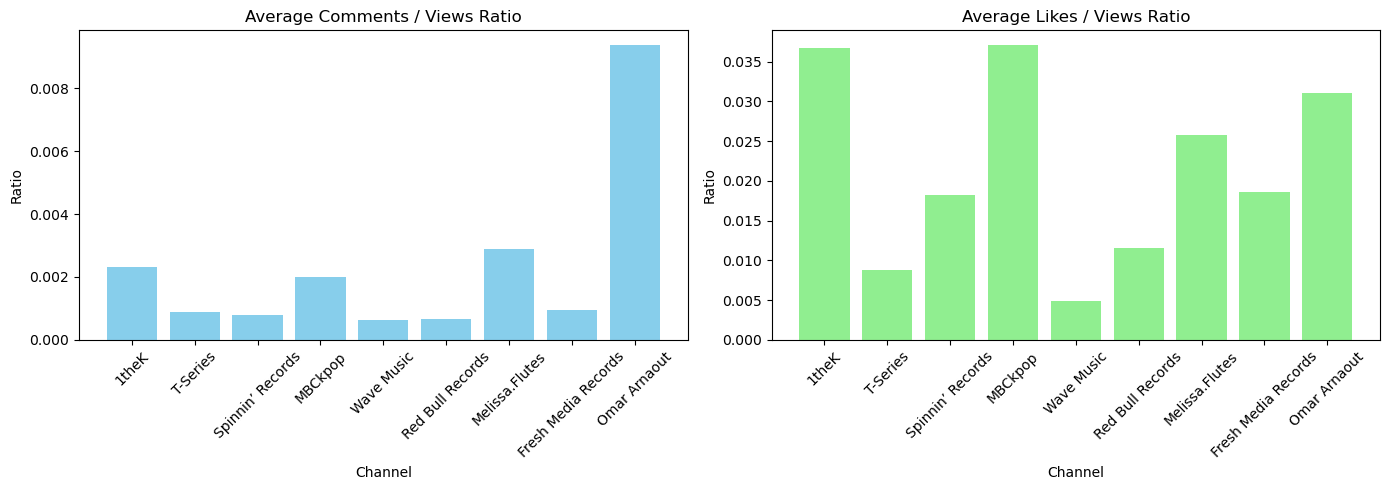

In [19]:

import matplotlib.pyplot as plt

# Create a DataFrame manually with all your results
ratios_df = pd.DataFrame({
    'channel_id': [
        'UCweOkPb1wVVH0Q0Tlj4a5Pw',
        'UCq-Fj5jknLsUf-MWSy4_brA',
        'UCpDJl2EmP7Oh90Vylx0dZtA',
        'UCe52oeb7Xv_KaJsEzcKXJJg',
        'UC22nIfOTM7KLIQuFGMKzQbg',
        'UC7qn3NBI3XV7d8I3cvZeABw',
        'UCrSpU-4ublLU9h8AA_Kkkzg',
        'UCQjHoPr0kqN83Mmihy7nsWw',
        'UCTF9pN56rhSs2xBC5qSoyeA'
    ],
    'comments_to_views': [
        avg_comm_views_ratio1,
        avg_comm_views_ratio2,
        avg_comm_views_ratio3,
        avg_comm_views_ratio4,
        avg_comm_views_ratio5,
        avg_comm_views_ratio6,
        avg_comm_views_ratio7,
        avg_comm_views_ratio8,
        avg_comm_views_ratio9
    ],
    'likes_to_views': [
        avg_likes_views_ratio1,
        avg_likes_views_ratio2,
        avg_likes_views_ratio3,
        avg_likes_views_ratio4,
        avg_likes_views_ratio5,
        avg_likes_views_ratio6,
        avg_likes_views_ratio7,
        avg_likes_views_ratio8,
        avg_likes_views_ratio9
    ]
})

channel_names = {
    'UCweOkPb1wVVH0Q0Tlj4a5Pw': '1theK',
    'UCq-Fj5jknLsUf-MWSy4_brA': 'T-Series',
    'UCpDJl2EmP7Oh90Vylx0dZtA': 'Spinnin’ Records',
    'UCe52oeb7Xv_KaJsEzcKXJJg': 'MBCkpop',
    'UC22nIfOTM7KLIQuFGMKzQbg': 'Wave Music',
    'UC7qn3NBI3XV7d8I3cvZeABw': 'Red Bull Records',
    'UCrSpU-4ublLU9h8AA_Kkkzg': 'Melissa.Flutes',
    'UCQjHoPr0kqN83Mmihy7nsWw': 'Fresh Media Records',
    'UCTF9pN56rhSs2xBC5qSoyeA': 'Omar Arnaout'
}

# Map names onto the dataframe
ratios_df['channel_name'] = ratios_df['channel_id'].map(channel_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar graph 1: Comments/Views
axes[0].bar(ratios_df['channel_name'], ratios_df['comments_to_views'], color='skyblue')
axes[0].set_title('Average Comments / Views Ratio')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Ratio')
axes[0].tick_params(axis='x', rotation=45)

# Bar graph 2: Likes/Views
axes[1].bar(ratios_df['channel_name'], ratios_df['likes_to_views'], color='lightgreen')
axes[1].set_title('Average Likes / Views Ratio')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Ratio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




